## Тензоры в PyTorch

In [1]:
import torch
torch.__version__

'2.4.1+cu121'

In [2]:
print(torch.cuda.get_device_name(0))  # изначально будет запускаться на GPU

NVIDIA GeForce RTX 4060 Laptop GPU


#### `Введение в понятие тензора`

In [3]:
t1 = torch.Tensor(3, 3)  # создает тензор заданной длины
t1

tensor([[0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.]])

In [4]:
t1.shape, t1.ndim, t1.type()  # (размер, количество размерностей, тип данных внутри)

(torch.Size([3, 3]), 2, 'torch.FloatTensor')

#### `Перевод массива в тензор`

In [5]:
import numpy as np

In [6]:
ar = np.array([[1, 2, 3], [4, 5, 6]])
t = torch.from_numpy(ar)  # тензор будет ссылаться на массив
t

tensor([[1, 2, 3],
        [4, 5, 6]], dtype=torch.int32)

In [7]:
t[0, 0] = 5
ar, t

(array([[5, 2, 3],
        [4, 5, 6]]),
 tensor([[5, 2, 3],
         [4, 5, 6]], dtype=torch.int32))

In [8]:
tt = torch.from_numpy(ar.copy())  # теперь тензор не ссылается на массив, а копирует его значения
ar[0, 0] = 1
ar, tt

(array([[1, 2, 3],
        [4, 5, 6]]),
 tensor([[5, 2, 3],
         [4, 5, 6]], dtype=torch.int32))

In [9]:
t_np = t.numpy()  # перевод тензора в массив
t_np

array([[1, 2, 3],
       [4, 5, 6]])

#### `Тензор с заданными значениями и размерностью`

In [10]:
torch.manual_seed(42)  # ставим ссемя рандома

In [11]:
torch.zeros(2, 3, dtype=torch.int32)  # тензор из нулей

tensor([[0, 0, 0],
        [0, 0, 0]], dtype=torch.int32)

In [12]:
torch.ones(2, 3, dtype=torch.int32)  # тензор из единиц

tensor([[1, 1, 1],
        [1, 1, 1]], dtype=torch.int32)

In [13]:
torch.eye(3)  # единичная матрица 3х3

tensor([[1., 0., 0.],
        [0., 1., 0.],
        [0., 0., 1.]])

In [14]:
torch.full((2, 3), 5)  # тензор размера (2, 3), который заполняется переданным значением 5

tensor([[5, 5, 5],
        [5, 5, 5]])

In [15]:
torch.arange(-6, 6, 2)  # арифметическая прогрессия от -6 до 6 с шагом 2

tensor([-6, -4, -2,  0,  2,  4])

In [16]:
torch.linspace(1, 5, 5)  # тензор со значениями от 1 до 5, в котором 5 значений с равным шагом изменения

tensor([1., 2., 3., 4., 5.])

In [17]:
torch.rand(2, 3)  # тензор размером (2. 3), который заполняется случайными величинами от 0 до 1 по нормальному распределению

tensor([[0.8823, 0.9150, 0.3829],
        [0.9593, 0.3904, 0.6009]])

In [18]:
torch.randn(2, 3)  # тензор размером (2. 3), который заполняется случайными величинами от -1 до 1, мат ожидание = 0

tensor([[ 1.1561,  0.3965, -2.4661],
        [ 0.3623,  0.3765, -0.1808]])

#### `Виды методов`

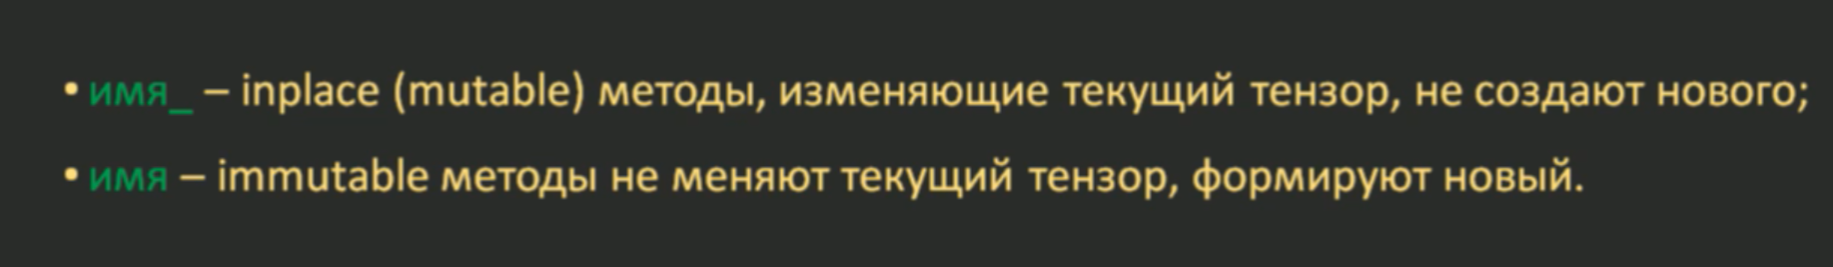

In [19]:
t = torch.FloatTensor(2, 5)

In [20]:
t

tensor([[0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0.]])

In [21]:
t.zero_()  # inplace метод zero_

tensor([[0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0.]])

In [22]:
torch.arange(7)  # immutable метод arange

tensor([0, 1, 2, 3, 4, 5, 6])

#### `Изменение размерности тензора`

In [40]:
t = torch.FloatTensor(27)
t

tensor([-2.3223e+26,  1.4447e-42,  0.0000e+00,  0.0000e+00,  0.0000e+00,
         0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,
         0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,
         0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,
         0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,
         0.0000e+00,  0.0000e+00])

In [41]:
t.view(3, 9)  # изменили размерность на (3, 5)

tensor([[-2.3223e+26,  1.4447e-42,  0.0000e+00,  0.0000e+00,  0.0000e+00,
          0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00],
        [ 0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,
          0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00],
        [ 0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,
          0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00]])

In [42]:
t.reshape(3, 3, 3)  # изменили размерность на (3, 3, 3)

tensor([[[-2.3223e+26,  1.4447e-42,  0.0000e+00],
         [ 0.0000e+00,  0.0000e+00,  0.0000e+00],
         [ 0.0000e+00,  0.0000e+00,  0.0000e+00]],

        [[ 0.0000e+00,  0.0000e+00,  0.0000e+00],
         [ 0.0000e+00,  0.0000e+00,  0.0000e+00],
         [ 0.0000e+00,  0.0000e+00,  0.0000e+00]],

        [[ 0.0000e+00,  0.0000e+00,  0.0000e+00],
         [ 0.0000e+00,  0.0000e+00,  0.0000e+00],
         [ 0.0000e+00,  0.0000e+00,  0.0000e+00]]])

In [43]:
t.resize_(2, 3)  # полностью изменили начальный тензор на (2, 3), взяв первые элементы

tensor([[-2.3223e+26,  1.4447e-42,  0.0000e+00],
        [ 0.0000e+00,  0.0000e+00,  0.0000e+00]])

In [45]:
t.ravel()  # получаем вектор из тензора

tensor([-2.3223e+26,  1.4447e-42,  0.0000e+00,  0.0000e+00,  0.0000e+00,
         0.0000e+00])

In [52]:
t.permute(1, 0)  # перевернули тензор (типо транспонировали)

tensor([[-2.3223e+26,  0.0000e+00],
        [ 1.4447e-42,  0.0000e+00],
        [ 0.0000e+00,  0.0000e+00]])

In [57]:
t.mT, t.T

(tensor([[-2.3223e+26,  0.0000e+00],
         [ 1.4447e-42,  0.0000e+00],
         [ 0.0000e+00,  0.0000e+00]]),
 tensor([[-2.3223e+26,  0.0000e+00],
         [ 1.4447e-42,  0.0000e+00],
         [ 0.0000e+00,  0.0000e+00]]))

#### `Добавление/удаление осей`

In [71]:
t = torch.arange(32).view(8, 2, 2)
t.shape

torch.Size([8, 2, 2])

In [72]:
t1 = torch.unsqueeze(t, dim=1)  # добавляем 1 ось
t1.shape

torch.Size([8, 1, 2, 2])

In [73]:
t2 = torch.squeeze(t1)  # удаляет все размерности, которые содержат ровно 1 элемент
t2.shape

torch.Size([8, 2, 2])

In [80]:
t3 = torch.squeeze(t1, dim=-1)  # удаляет заданную размерность тензора, если она содержит 1 элемент
t4 = torch.squeeze(t1, dim=1)
t3.shape, t4.shape

(torch.Size([8, 1, 2, 2]), torch.Size([8, 2, 2]))

#### `Индексирование и срезы`

Одномерный случай

In [88]:
t = torch.arange(12)
t[-1].item(), t[-1]  # само число, тензор с нужным элементом

(11, tensor(11))

In [90]:
t[-1] = 100  # изменение тензора
t

tensor([  0,   1,   2,   3,   4,   5,   6,   7,   8,   9,  10, 100])

In [91]:
t[:4] = torch.IntTensor([-1, -2, -3, -4])
t

tensor([ -1,  -2,  -3,  -4,   4,   5,   6,   7,   8,   9,  10, 100])

Многомерный случай

In [98]:
t = torch. IntTensor([(1, 2, 3), (10, 20, 30), (100, 200, 300)])
t

tensor([[  1,   2,   3],
        [ 10,  20,  30],
        [100, 200, 300]], dtype=torch.int32)

In [99]:
t[0], t[0, 0]

(tensor([1, 2, 3], dtype=torch.int32), tensor(1, dtype=torch.int32))

In [100]:
t[:, 1]  # первый столбец тензора

tensor([  2,  20, 200], dtype=torch.int32)

In [101]:
t[..., 1]  # вместо ... подставляеются все значения для пропущенных размерностей

tensor([  2,  20, 200], dtype=torch.int32)

In [103]:
t = torch.arange(10)
t

tensor([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])

In [110]:
a = t[[0, 2, -1]]  # создается новый тензор, содержащий значения под заданными индексами

In [111]:
a[[0, -1]] = 100  # значения под заданными индексами изменяются
a, t

(tensor([100,   2, 100]), tensor([0, 1, 2, 3, 4, 5, 6, 7, 8, 9]))

#### `Основные математические операции`

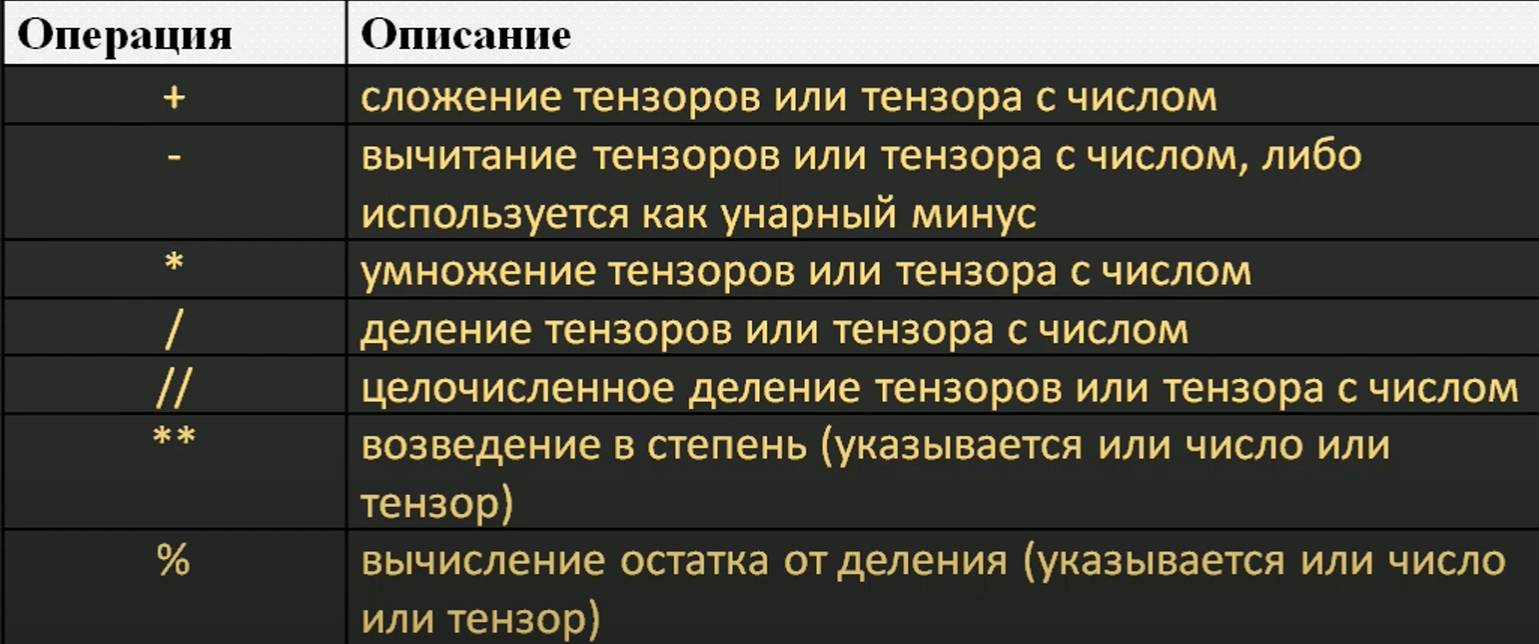

Поэлементные операции

In [116]:
t = torch.FloatTensor([[1, 2, 3], [4, 5, 6]])

In [117]:
t - 3  # от каждого значения внутри тензора отнимается 3

tensor([[-2., -1.,  0.],
        [ 1.,  2.,  3.]])

In [119]:
-t  # все значения становятся отрицательными

tensor([[-1., -2., -3.],
        [-4., -5., -6.]])

In [120]:
t * 2  # каждое значение умножается на 2

tensor([[ 2.,  4.,  6.],
        [ 8., 10., 12.]])

In [121]:
t ** 3  # каждое значение возводится в куб

tensor([[  1.,   8.,  27.],
        [ 64., 125., 216.]])

In [126]:
t1 = torch.FloatTensor([4, 5, 6])

In [127]:
t - t1  # вычитаются соответственные значения в тензорах (то же самое для др операций)

tensor([[-3., -3., -3.],
        [ 0.,  0.,  0.]])

#### `Статестические и математические функции`

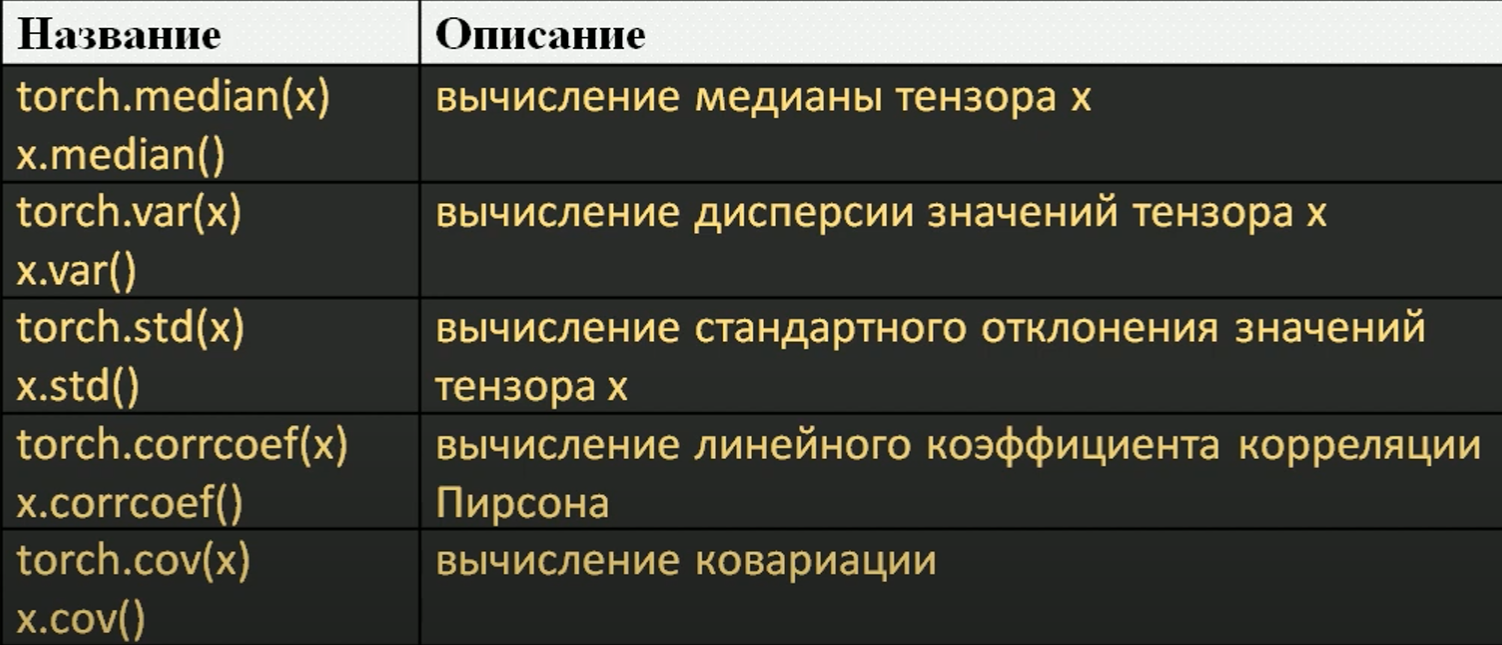

In [131]:
a = torch.arange(12)
a.max()

tensor(11)

In [133]:
b = torch.arange(12).view(3, 4)
b.max()  # применяется вне зависимости от размерности тензора

tensor(11)

In [134]:
b

tensor([[ 0,  1,  2,  3],
        [ 4,  5,  6,  7],
        [ 8,  9, 10, 11]])

In [140]:
b.sum(dim=0), b.sum(dim=1)  # сумма вычисляется по переданной размерности (0 - столбец, 1 - строка)

(tensor([12, 15, 18, 21]), tensor([ 6, 22, 38]))

In [148]:
b.max(dim=0)  # сами максимальные значения и их индексы в размерности

torch.return_types.max(
values=tensor([ 8,  9, 10, 11]),
indices=tensor([2, 2, 2, 2]))

In [149]:
b.amax()  # самое наибольшее число в тензоре

tensor(11)

In [161]:
a = torch.linspace(0, torch.pi, 12)

In [154]:
a.sin()  # применение функции синуса к каждому элемену

tensor([ 0.0000e+00,  3.4202e-01,  6.4279e-01,  8.6603e-01,  9.8481e-01,
         9.8481e-01,  8.6603e-01,  6.4279e-01,  3.4202e-01, -8.7423e-08])

In [168]:
a = torch.rand(3, 4)
b = torch.randn(3, 4)

In [171]:
ab = torch.vstack([a, b])  # соединяем 2 тензора в 1
ab

tensor([[ 0.2666,  0.6274,  0.2696,  0.4414],
        [ 0.2969,  0.8317,  0.1053,  0.2695],
        [ 0.3588,  0.1994,  0.5472,  0.0062],
        [-0.3267, -0.2788, -0.4220, -1.3323],
        [-0.3639,  0.1513, -0.3514, -0.7906],
        [-0.0915,  0.2352,  2.2440,  0.5817]])

In [172]:
ab.corrcoef()  # матрица корреляции

tensor([[ 1.0000,  0.8939, -0.6331, -0.0661,  0.4934, -0.3866],
        [ 0.8939,  1.0000, -0.3953,  0.3277,  0.7595, -0.5644],
        [-0.6331, -0.3953,  1.0000,  0.7081,  0.2963,  0.5862],
        [-0.0661,  0.3277,  0.7081,  1.0000,  0.8318, -0.0037],
        [ 0.4934,  0.7595,  0.2963,  0.8318,  1.0000, -0.1450],
        [-0.3866, -0.5644,  0.5862, -0.0037, -0.1450,  1.0000]])

In [173]:
ab.cov()  # ковариационная матрциа

tensor([[ 0.0294,  0.0484, -0.0250, -0.0057,  0.0326, -0.0688],
        [ 0.0484,  0.0995, -0.0287,  0.0515,  0.0923, -0.1848],
        [-0.0250, -0.0287,  0.0530,  0.0813,  0.0263,  0.1401],
        [-0.0057,  0.0515,  0.0813,  0.2485,  0.1597, -0.0019],
        [ 0.0326,  0.0923,  0.0263,  0.1597,  0.1484, -0.0580],
        [-0.0688, -0.1848,  0.1401, -0.0019, -0.0580,  1.0778]])